# 03 - Heatmaps And Report Artifact Explorer

This notebook recreates compact versions of the interaction heatmaps in `outputs/reports/metric_analysis/rendered/metric_analysis.tex` and inspects the generated report artifacts.

Use small grids while exploring. Increase the grid size only when you need report-quality detail.

In [1]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_dir(start: Path) -> Path:
    current = Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "configs" / "baseline.yaml").exists() and (
            candidate / "simulation" / "config_loader.py"
        ).exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root from the current notebook location.")


REPO_DIR = find_repo_dir(Path.cwd())
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from analysis.metrics import (
    METRIC_DEFINITIONS,
    aggregate_result_row,
    class_result_rows,
    metric_definition_rows,
    outcome_rates_from_result,
    outcome_totals,
    result_metrics_from_result,
)
from analysis.plot_style import (
    BASELINE_COLOR,
    driver_heatmap_cmap,
    driver_line_style,
    plot_driver_line,
)
from simulation.config_loader import load_config
from simulation.engine import ClinicAppointmentSimulation
from simulation.model import ThresholdRule

BASE_CONFIG = load_config(REPO_DIR / "configs" / "baseline.yaml")
pd.options.display.max_columns = 120

from matplotlib.colors import TwoSlopeNorm
import json

## Reusable Grid And Heatmap Helpers

`grid_records` is intentionally small and explicit so it is easy to adapt for new metrics.

In [2]:
def make_step_rule(old_rule: ThresholdRule, threshold=None, step=None) -> ThresholdRule:
    threshold = old_rule.threshold if threshold is None else int(threshold)
    low = old_rule.low
    step = old_rule.high - old_rule.low if step is None else float(step)
    return ThresholdRule(threshold=threshold, low=low, high=min(low + step, 1.0))


def update_classes(config, changes):
    classes = {}
    for class_id, params in config.classes.items():
        classes[class_id] = replace(params, **changes.get(class_id, {}))
    return replace(config, classes=classes)


def set_balk_steps(config, class_1_step, class_2_step):
    return update_classes(
        config,
        {
            1: {"balk_prob": make_step_rule(config.classes[1].balk_prob, step=class_1_step)},
            2: {"balk_prob": make_step_rule(config.classes[2].balk_prob, step=class_2_step)},
        },
    )


def set_cancel_probs(config, class_1_cancel, class_2_cancel):
    return update_classes(
        config,
        {
            1: {"cancel_prob": float(class_1_cancel)},
            2: {"cancel_prob": float(class_2_cancel)},
        },
    )


def grid_records(x_values, y_values, x_name, y_name, config_builder, seed=2027):
    rows = []
    for x in x_values:
        for y in y_values:
            config = replace(config_builder(BASE_CONFIG, x, y), seed=seed)
            result = ClinicAppointmentSimulation(config).run()
            rows.append({x_name: x, y_name: y, **result_metrics_from_result(result)})
    return pd.DataFrame(rows)


def draw_heatmap(df, x_name, y_name, metric, title, driver, diverging=False):
    table = df.pivot(index=y_name, columns=x_name, values=metric).sort_index()
    fig, ax = plt.subplots(figsize=(7, 5))
    cmap = driver_heatmap_cmap(driver, diverging=diverging)
    norm = None
    if diverging:
        max_abs = float(np.nanmax(np.abs(table.values)))
        norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs) if max_abs else None
    image = ax.imshow(table.values, origin="lower", aspect="auto", cmap=cmap, norm=norm)
    ax.set_title(title)
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.set_xticks(range(len(table.columns)))
    ax.set_xticklabels([f"{v:.2g}" for v in table.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(table.index)))
    ax.set_yticklabels([f"{v:.2g}" for v in table.index])
    fig.colorbar(image, ax=ax, shrink=0.85)
    fig.tight_layout()
    return fig

## Balking Step Interaction

This compact grid mirrors the report's balking-step heatmaps.

,class_1_balk_step,class_2_balk_step,average_utilization,overall_percent_serviced,mean_accepted_booking_delay,mean_offered_booking_delay,class_1_percent_serviced,class_2_percent_serviced,overall_balking_rate,class_1_balking_rate,class_2_balking_rate,class_1_slot_utilization,class_2_slot_utilization,class_1_mean_offered_booking_delay,class_2_mean_offered_booking_delay,access_advantage_class_1,balking_rate_gap_class_1,delay_advantage_class_1
0,0.0,0.0,0.839983,0.266074,9.455949,9.455949,0.265105,0.267039,0.000000,0.0,0.000000,0.416610,0.422003,9.467413,9.444488,-0.001934,0.000000,-0.022926
1,0.0,0.2,0.842979,0.269317,9.461352,9.644081,0.275754,0.262931,0.059320,0.0,0.117763,0.429709,0.413014,9.660260,9.628141,0.012823,-0.117763,-0.032119
2,0.0,0.4,0.842295,0.269737,9.422320,9.829819,0.288214,0.251397,0.130971,0.0,0.260922,0.447003,0.392808,9.866013,9.793906,0.036817,-0.260922,-0.072106
3,0.0,0.6,0.833818,0.263077,9.453964,10.083305,0.299362,0.227295,0.205333,0.0,0.407394,0.470034,0.361901,10.089886,10.076828,0.072067,-0.407394,-0.013058
4,0.0,0.8,0.843236,0.266763,9.382206,10.224798,0.322060,0.211234,0.280630,0.0,0.563010,0.508733,0.332277,10.230639,10.218920,0.110826,-0.563010,-0.011719


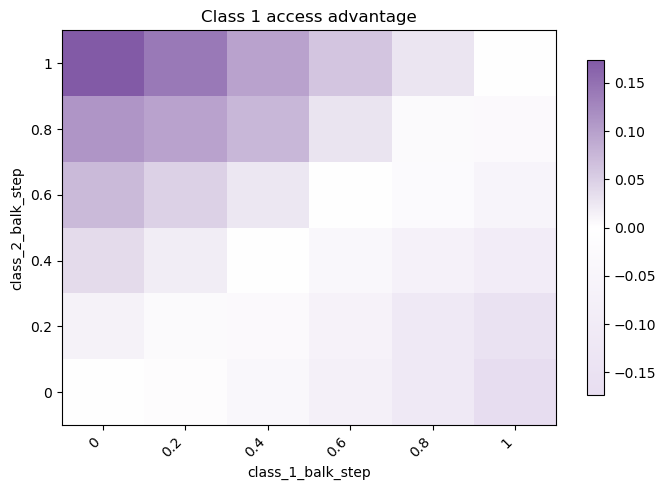

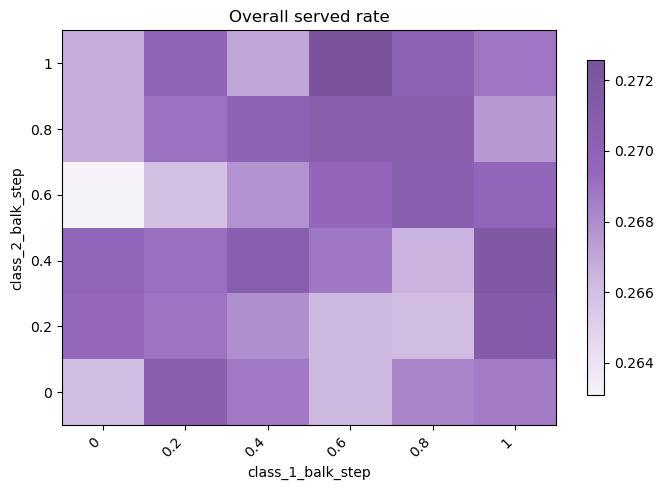

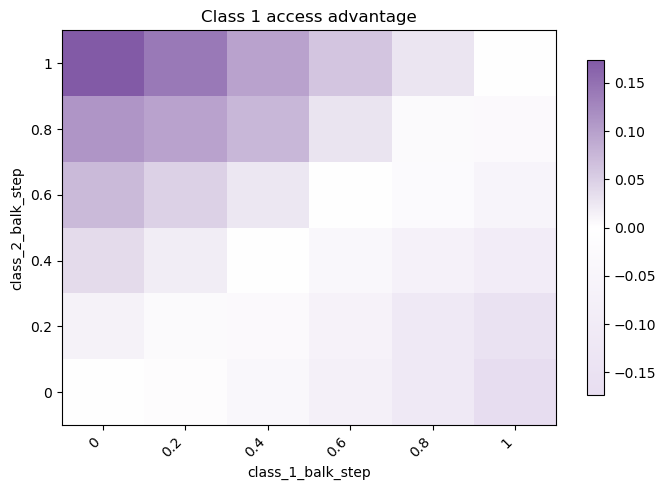

In [3]:
STEP_VALUES = np.linspace(0.0, 1.0, 6)

balk_grid = grid_records(
    STEP_VALUES,
    STEP_VALUES,
    "class_1_balk_step",
    "class_2_balk_step",
    set_balk_steps,
)

display(balk_grid.head())
draw_heatmap(balk_grid, "class_1_balk_step", "class_2_balk_step", "overall_percent_serviced", "Overall served rate", "balking")
draw_heatmap(balk_grid, "class_1_balk_step", "class_2_balk_step", "access_advantage_class_1", "Class 1 access advantage", "balking", diverging=True)

## Cancellation Interaction

Cancellation has one of the strongest class-gap effects in the report.

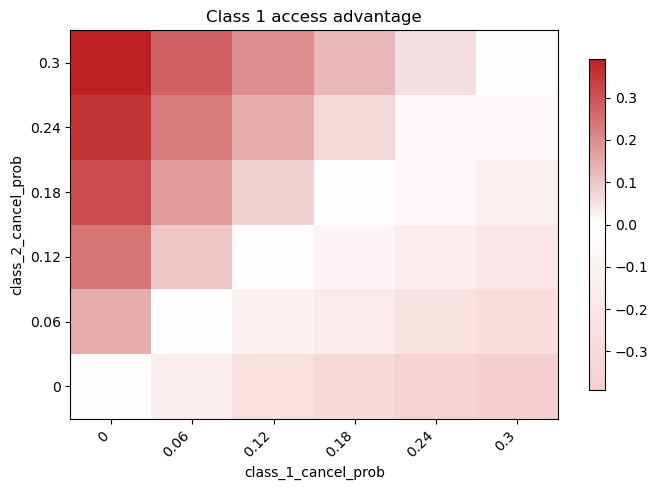

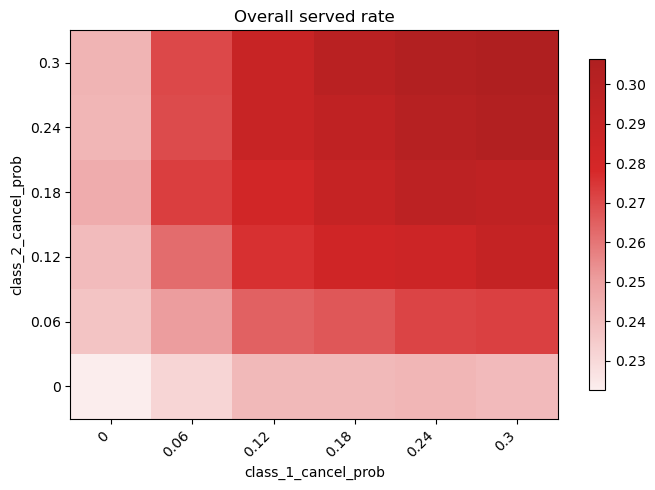

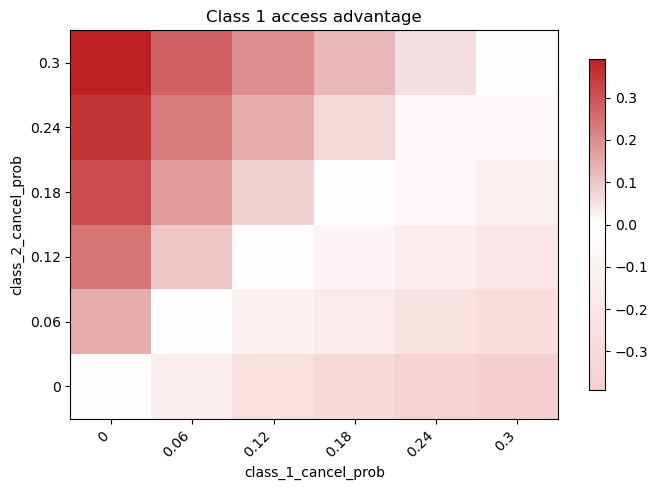

In [4]:
CANCEL_VALUES = np.linspace(0.0, 0.30, 6)

cancel_grid = grid_records(
    CANCEL_VALUES,
    CANCEL_VALUES,
    "class_1_cancel_prob",
    "class_2_cancel_prob",
    set_cancel_probs,
)

draw_heatmap(cancel_grid, "class_1_cancel_prob", "class_2_cancel_prob", "overall_percent_serviced", "Overall served rate", "cancellation")
draw_heatmap(cancel_grid, "class_1_cancel_prob", "class_2_cancel_prob", "access_advantage_class_1", "Class 1 access advantage", "cancellation", diverging=True)

## Inspect Generated Report Artifacts

The manifest is written by `scripts/generate_metric_analysis_figures.py` and records the command, config hashes, package versions, seeds, grids, row counts, and artifacts generated in that run.

In [5]:
manifest_path = REPO_DIR / "outputs" / "reports" / "metric_analysis" / "manifest.json"
manifest = json.loads(manifest_path.read_text())

print("command:", " ".join(manifest["command"]))
print("git:", manifest["git"])
print("generated artifacts:", len(manifest["generated_artifacts"]))

display(pd.Series(manifest["row_counts"], name="rows").to_frame())
display(pd.Series(manifest["environment"]["packages"], name="version").to_frame())

command: python scripts/generate_metric_analysis_figures.py
git: {'commit': '97d5e3e58f66f0a4e95f064b741766d35789849a', 'dirty': True}
generated artifacts: 65


,rows
arrival_mix_grid,187
balking_class1_step_slice,21
balking_class1_threshold_slice,14
balking_step_grid,441
balking_threshold_grid,196
balking_threshold_jump_grid,294
cancellation_grid,441
class_arrival_grid,42
fcfs_capacity_stress,15
no_show_step_grid,441


,version
jupyter,1.1.1
matplotlib,3.10.0
numpy,1.26.4
pandas,2.2.3
pyyaml,6.0.2


## Open Existing Report Figures

Use this cell to inspect any generated figure without leaving the notebook.
Change `figure_name` to another file listed in the manifest.

/Users/alexandresepulvedadedietrich/CUIMC-Appointment-Simulation/outputs/reports/metric_analysis/figures/metric_access_drivers.png


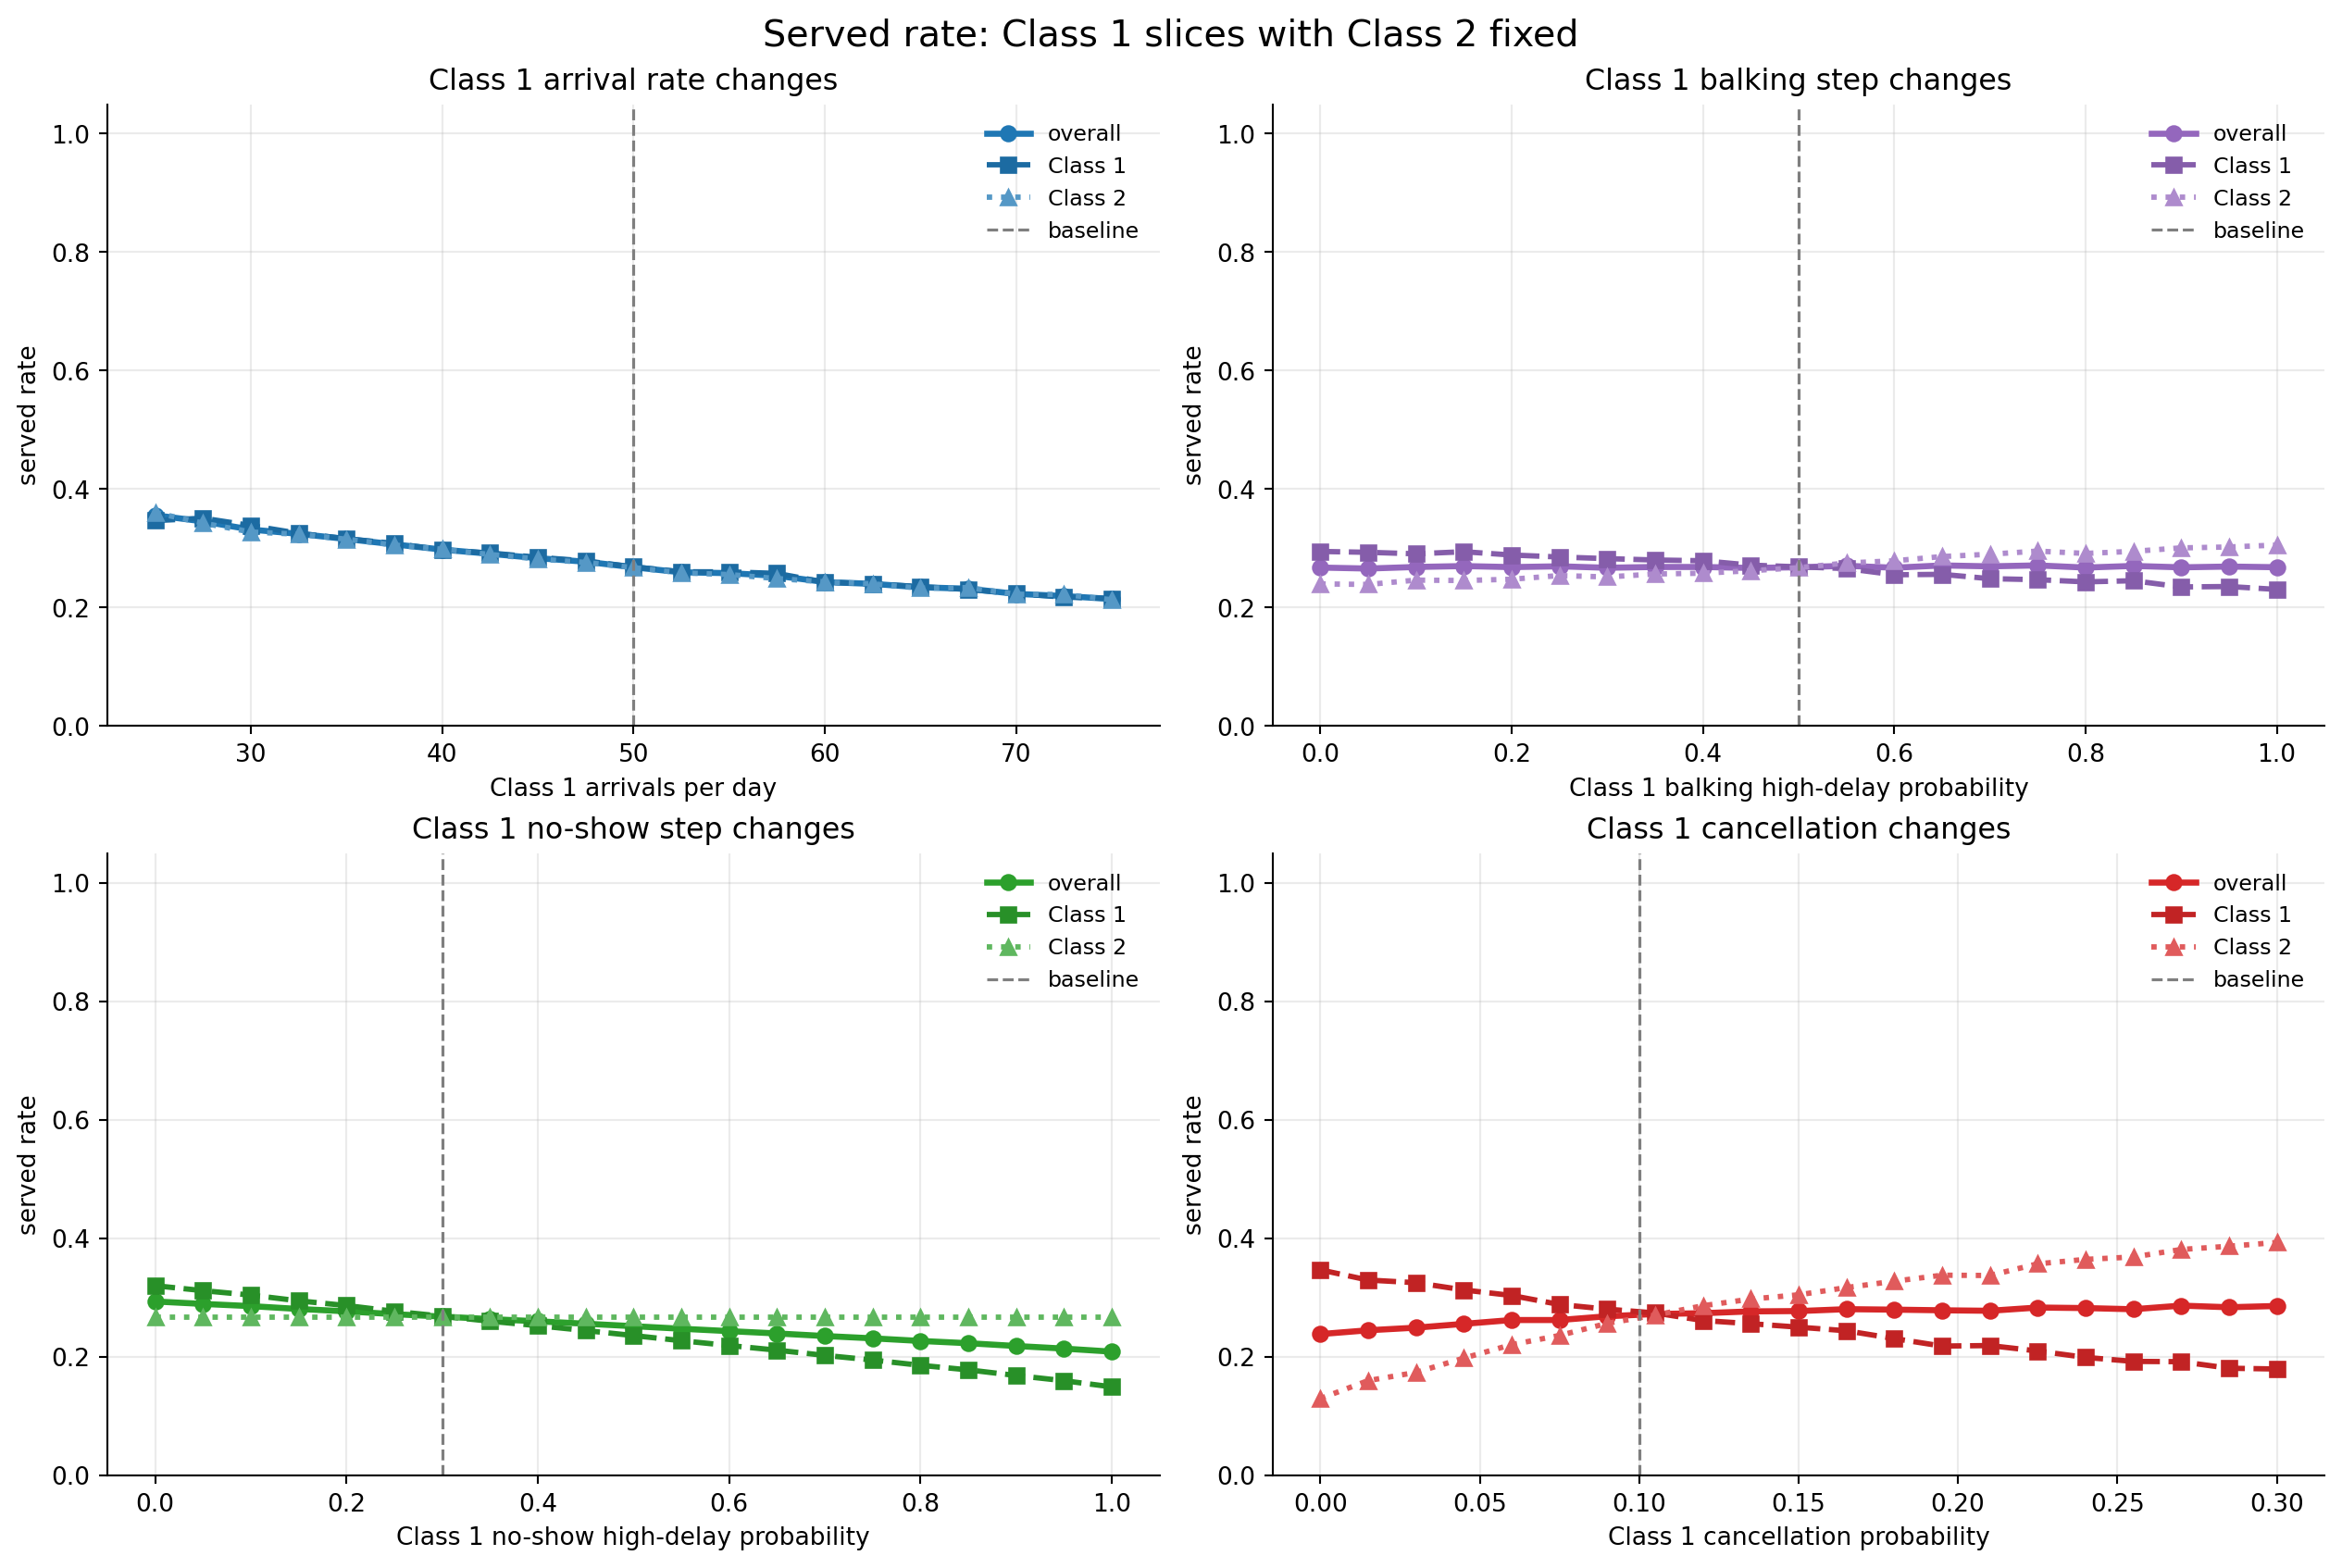

In [6]:
from IPython.display import Image, display

figure_name = "metric_access_drivers.png"
figure_path = REPO_DIR / "outputs" / "reports" / "metric_analysis" / "figures" / figure_name
print(figure_path)
display(Image(filename=str(figure_path)))